# Notebook 06: Backtesting and Statistical Validation

This notebook implements comprehensive VaR backtesting:

1. **Basel III Traffic Light Framework** - Regulatory backtesting
2. **Static Backtesting** - Fixed VaR from training period
3. **Rolling Backtesting** - Dynamic VaR updates
4. **Kupiec Test (POF)** - Proportion of Failures test
5. **Christoffersen Test** - Independence of violations
6. **Comprehensive Model Comparison** - All VaR methods

---

## 6.1 Basel III Traffic Light Framework

The Basel Committee on Banking Supervision (BCBS) established a traffic light approach for evaluating VaR models:

| Zone | Exceptions (250 days) | Multiplier Increase | Interpretation |
|------|----------------------|---------------------|----------------|
| **Green** | 0-4 | 0.00 | Model accepted |
| **Yellow** | 5-9 | 0.40-0.85 | Model under scrutiny |
| **Red** | 10+ | 1.00 | Model rejected |

### Expected Violations

For 99% VaR over 250 trading days:
- Expected violations: 250 × 1% = 2.5
- Acceptable range: 0-4 (within 2σ of expected)

**Reference**: [BCBS Supervisory Framework for Backtesting](https://www.bis.org/publ/bcbs22.pdf)

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import json
import warnings
warnings.filterwarnings('ignore')

# Statistical
from scipy.stats import norm, chi2, binom

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display
from IPython.display import display, Markdown
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

np.random.seed(42)
print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load configuration and data
with open('../portfolio_config.json', 'r') as f:
    config = json.load(f)

CONFIDENCE = config['var_params']['confidence_var']
TRAIN_START = config['dates']['train_start']
TRAIN_END = config['dates']['train_end']
TEST_START = config['dates']['test_start']
TEST_END = config['dates']['test_end']
WINDOW = config['var_params']['rolling_window']

# Load returns
portfolio_returns = pd.read_csv('../outputs/portfolio_returns.csv', index_col=0, parse_dates=True)['portfolio_return']
train_returns = portfolio_returns[TRAIN_START:TRAIN_END]
test_returns = portfolio_returns[TEST_START:TEST_END]

# Load VaR results from previous notebooks
with open('../outputs/var_results.json', 'r') as f:
    var_results = json.load(f)

print(f"Training period: {len(train_returns)} days")
print(f"Testing period: {len(test_returns)} days")
print(f"Confidence level: {CONFIDENCE*100:.0f}%")

Training period: 731 days
Testing period: 249 days
Confidence level: 99%


## 6.2 Backtesting Functions

In [ ]:
def basel_zone(violations):
    """
    Determine Basel III traffic light zone based on number of violations.
    
    Basel Committee framework for 250-day backtesting at 99% confidence:
    - Green (0-4): Model is acceptable
    - Yellow (5-9): Model under scrutiny, capital multiplier increases
    - Red (10+): Model rejected, maximum capital multiplier
    
    Parameters:
    -----------
    violations : int
        Number of VaR violations in backtesting period
        
    Returns:
    --------
    tuple
        (zone_name, color, multiplier_increase)
    """
    if violations <= 4:
        # Green zone: Model performs as expected
        # Expected violations at 99% over 250 days: 2.5
        # Statistical tolerance: 0-4 is within ~2 standard deviations
        return ('Green', 'green', 0.00)
    elif violations <= 9:
        # Yellow zone: Model may be underestimating risk
        # Progressive capital multiplier increase
        multipliers = {5: 0.40, 6: 0.50, 7: 0.65, 8: 0.75, 9: 0.85}
        return ('Yellow', 'yellow', multipliers.get(violations, 0.85))
    else:
        # Red zone: Model is clearly inadequate
        # Maximum capital multiplier penalty
        return ('Red', 'red', 1.00)

def backtest_var(actual_returns, var_threshold):
    """
    Perform VaR backtesting - compare actual returns against VaR predictions.
    
    A "violation" occurs when actual loss exceeds VaR prediction.
    
    Parameters:
    -----------
    actual_returns : pd.Series
        Actual portfolio returns during test period
    var_threshold : float or pd.Series
        VaR threshold(s) - can be static (single value) or rolling (series)
        
    Returns:
    --------
    dict
        Comprehensive backtesting results
    """
    # Handle both static VaR (single number) and rolling VaR (time series)
    if isinstance(var_threshold, (int, float)):
        # Static VaR: Same threshold for all days
        violations = actual_returns < var_threshold
    else:
        # Rolling VaR: Align indices and compare day-by-day
        common_idx = actual_returns.index.intersection(var_threshold.index)
        actual_returns = actual_returns.loc[common_idx]
        var_threshold = var_threshold.loc[common_idx]
        violations = actual_returns < var_threshold
    
    # Count violations and calculate rates
    num_violations = violations.sum()
    total_days = len(actual_returns)
    violation_rate = num_violations / total_days      # Observed rate
    expected_rate = 1 - CONFIDENCE                    # Expected rate (1% for 99% VaR)
    
    # Determine Basel zone
    zone, color, multiplier = basel_zone(num_violations)
    
    return {
        'violations': int(num_violations),
        'total_days': total_days,
        'violation_rate': violation_rate,
        'expected_rate': expected_rate,
        'zone': zone,
        'color': color,
        'multiplier_increase': multiplier,
        'violation_dates': actual_returns.index[violations].tolist(),
        'violation_returns': actual_returns[violations].tolist()
    }

## 6.3 Static Backtesting

In [4]:
# Get VaR estimates from training period
param_var = var_results['parametric']['var_1d']
hist_var = var_results['historical']['var_1d']
mc_var = var_results['monte_carlo']['var_1d']

print("Static VaR Estimates (from training period):")
print(f"  Parametric VaR: {param_var:.4%}")
print(f"  Historical VaR: {hist_var:.4%}")
print(f"  Monte Carlo VaR: {mc_var:.4%}")

Static VaR Estimates (from training period):
  Parametric VaR: -4.4121%
  Historical VaR: -4.8906%
  Monte Carlo VaR: -4.4009%


In [5]:
# Perform static backtesting
static_results = {
    'Parametric': backtest_var(test_returns, param_var),
    'Historical': backtest_var(test_returns, hist_var),
    'Monte Carlo': backtest_var(test_returns, mc_var)
}

# Summary table
static_summary = pd.DataFrame({
    'Method': static_results.keys(),
    'VaR': [f"{abs(v):.2%}" for v in [param_var, hist_var, mc_var]],
    'Violations': [r['violations'] for r in static_results.values()],
    'Total Days': [r['total_days'] for r in static_results.values()],
    'Violation Rate': [f"{r['violation_rate']:.2%}" for r in static_results.values()],
    'Expected Rate': [f"{r['expected_rate']:.2%}" for r in static_results.values()],
    'Basel Zone': [r['zone'] for r in static_results.values()]
})

display(Markdown("### Static Backtesting Results (Test Period)"))
display(static_summary)

### Static Backtesting Results (Test Period)

,Method,VaR,Violations,Total Days,Violation Rate,Expected Rate,Basel Zone
0,Parametric,4.41%,6,249,2.41%,1.00%,Yellow
1,Historical,4.89%,2,249,0.80%,1.00%,Green
2,Monte Carlo,4.40%,6,249,2.41%,1.00%,Yellow


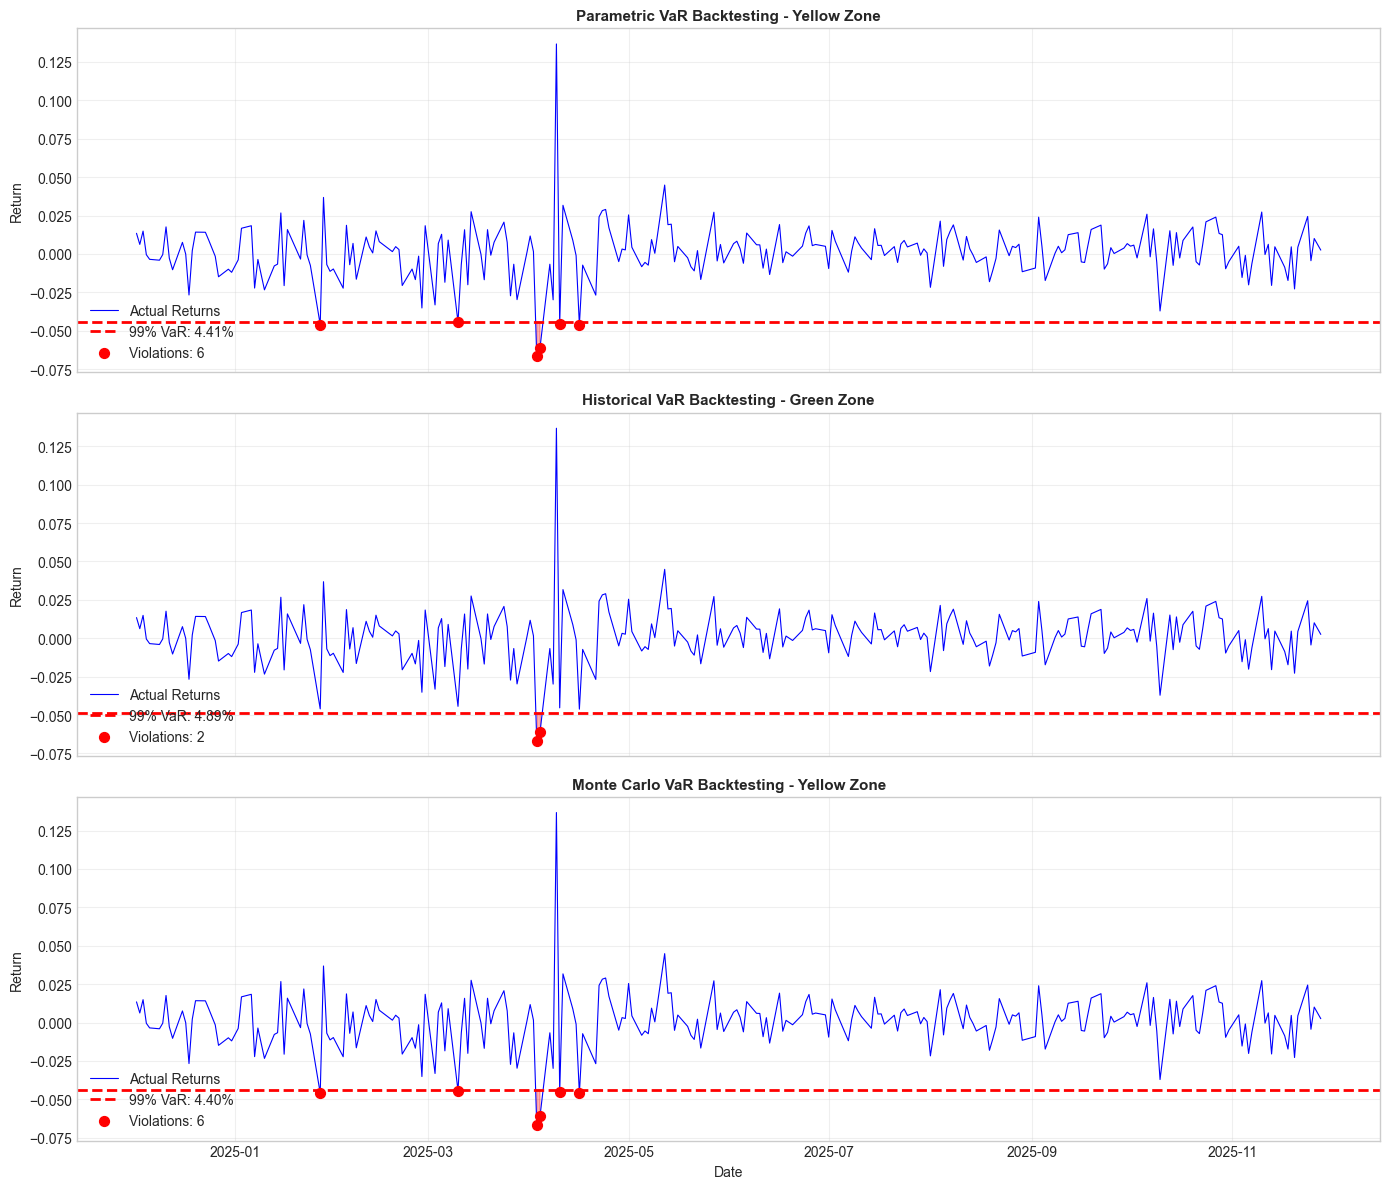

In [6]:
# Visualize static backtesting
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

methods = ['Parametric', 'Historical', 'Monte Carlo']
var_values = [param_var, hist_var, mc_var]

for i, (method, var) in enumerate(zip(methods, var_values)):
    ax = axes[i]
    result = static_results[method]
    
    # Plot returns
    ax.plot(test_returns.index, test_returns.values, color='blue', linewidth=0.8, label='Actual Returns')
    ax.axhline(var, color='red', linestyle='--', linewidth=2, label=f'99% VaR: {abs(var):.2%}')
    
    # Highlight violations
    violations_mask = test_returns < var
    ax.scatter(test_returns.index[violations_mask], test_returns[violations_mask], 
               color='red', s=50, zorder=5, label=f'Violations: {result["violations"]}')
    
    # Fill violation area
    ax.fill_between(test_returns.index, var, test_returns.values, 
                    where=test_returns.values < var, color='red', alpha=0.3)
    
    ax.set_title(f'{method} VaR Backtesting - {result["zone"]} Zone', fontsize=11, fontweight='bold')
    ax.set_ylabel('Return')
    ax.legend(loc='lower left')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.savefig('../outputs/figures/06_static_backtesting.png', dpi=300, bbox_inches='tight')
plt.show()

## 6.4 Rolling Backtesting

In [7]:
def rolling_var_backtest(returns, window=250, confidence=0.99, method='historical'):
    """
    Perform rolling VaR backtesting.
    
    Parameters:
    -----------
    returns : pd.Series
        Full return series
    window : int
        Rolling window size
    confidence : float
        VaR confidence level
    method : str
        'historical', 'parametric', or 'monte_carlo'
        
    Returns:
    --------
    pd.DataFrame
        Rolling backtest results
    """
    results = []
    
    for i in range(window, len(returns)):
        train = returns.iloc[i-window:i]
        actual = returns.iloc[i]
        date = returns.index[i]
        
        if method == 'historical':
            var = np.percentile(train, (1 - confidence) * 100)
        elif method == 'parametric':
            mu, sigma = train.mean(), train.std()
            var = mu + norm.ppf(1 - confidence) * sigma
        elif method == 'monte_carlo':
            mu, sigma = train.mean(), train.std()
            simulated = np.random.normal(mu, sigma, 10000)
            var = np.percentile(simulated, (1 - confidence) * 100)
        
        results.append({
            'Date': date,
            'Actual_Return': actual,
            'Rolling_VaR': var,
            'Violation': actual < var
        })
    
    return pd.DataFrame(results).set_index('Date')

In [8]:
# Perform rolling backtesting for each method
print("Calculating rolling VaR backtests...")

rolling_hist = rolling_var_backtest(portfolio_returns, window=WINDOW, confidence=CONFIDENCE, method='historical')
rolling_param = rolling_var_backtest(portfolio_returns, window=WINDOW, confidence=CONFIDENCE, method='parametric')
rolling_mc = rolling_var_backtest(portfolio_returns, window=WINDOW, confidence=CONFIDENCE, method='monte_carlo')

# Filter to test period
rolling_hist_test = rolling_hist[TEST_START:TEST_END]
rolling_param_test = rolling_param[TEST_START:TEST_END]
rolling_mc_test = rolling_mc[TEST_START:TEST_END]

print(f"Rolling backtests calculated for {len(rolling_hist_test)} days in test period")

Calculating rolling VaR backtests...


Rolling backtests calculated for 249 days in test period


In [9]:
# Rolling backtest summary
rolling_summary = pd.DataFrame({
    'Method': ['Parametric', 'Historical', 'Monte Carlo'],
    'Violations': [
        rolling_param_test['Violation'].sum(),
        rolling_hist_test['Violation'].sum(),
        rolling_mc_test['Violation'].sum()
    ],
    'Total Days': [
        len(rolling_param_test),
        len(rolling_hist_test),
        len(rolling_mc_test)
    ]
})

rolling_summary['Violation Rate'] = rolling_summary['Violations'] / rolling_summary['Total Days']
rolling_summary['Basel Zone'] = rolling_summary['Violations'].apply(lambda x: basel_zone(x)[0])

display(Markdown("### Rolling Backtesting Results (Test Period)"))
display(rolling_summary)

### Rolling Backtesting Results (Test Period)

,Method,Violations,Total Days,Violation Rate,Basel Zone
0,Parametric,7,249,0.0281,Yellow
1,Historical,4,249,0.0161,Green
2,Monte Carlo,7,249,0.0281,Yellow


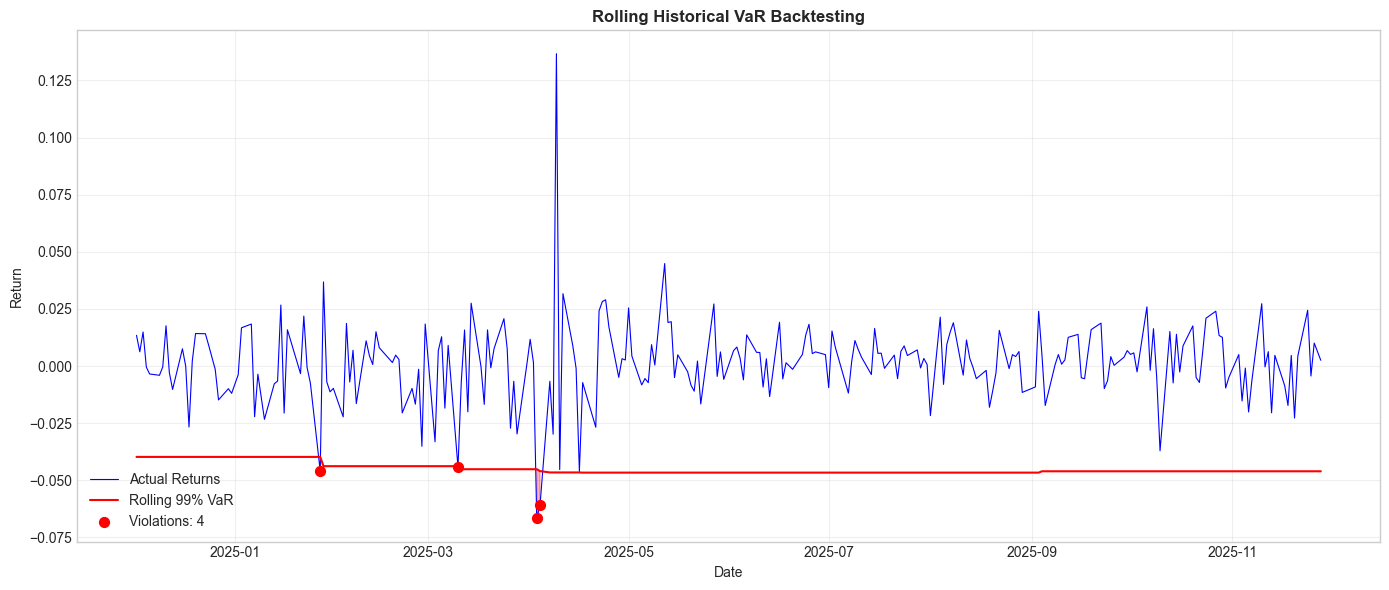

In [10]:
# Visualize rolling backtesting
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(rolling_hist_test.index, rolling_hist_test['Actual_Return'], 
        color='blue', linewidth=0.8, label='Actual Returns')
ax.plot(rolling_hist_test.index, rolling_hist_test['Rolling_VaR'], 
        color='red', linewidth=1.5, label='Rolling 99% VaR')

# Highlight violations
violations = rolling_hist_test[rolling_hist_test['Violation']]
ax.scatter(violations.index, violations['Actual_Return'], 
           color='red', s=50, zorder=5, label=f'Violations: {len(violations)}')

ax.fill_between(rolling_hist_test.index, 
                rolling_hist_test['Rolling_VaR'], 
                rolling_hist_test['Actual_Return'],
                where=rolling_hist_test['Violation'],
                color='red', alpha=0.3)

ax.set_title('Rolling Historical VaR Backtesting', fontsize=12, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Return')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/06_rolling_backtesting.png', dpi=300, bbox_inches='tight')
plt.show()

## 6.5 Kupiec Test (Proportion of Failures)

The Kupiec test evaluates whether the observed violation rate equals the expected rate.

### Hypothesis
- H₀: p = α (violation rate equals expected)
- H₁: p ≠ α

### Test Statistic (Likelihood Ratio)

$$LR_{POF} = -2 \ln\left[\frac{(1-\alpha)^{T-x} \alpha^x}{(1-\hat{p})^{T-x} \hat{p}^x}\right]$$

Where:
- α = expected violation rate (1 - confidence)
- x = observed violations
- T = total observations
- p̂ = x/T (observed violation rate)

Under H₀, LR ~ χ²(1)

In [ ]:
def kupiec_test(violations, total_days, confidence=0.99):
    """
    Perform Kupiec POF (Proportion of Failures) test.
    
    Tests whether the observed violation rate equals the expected rate.
    
    Hypothesis:
    - H₀: p = α (violation rate equals expected)
    - H₁: p ≠ α (violation rate differs from expected)
    
    Test Statistic (Likelihood Ratio):
    LR = -2 × ln[(1-α)^(T-x) × α^x / (1-p̂)^(T-x) × p̂^x]
    
    Under H₀, LR ~ χ²(1)
    
    Parameters:
    -----------
    violations : int
        Number of VaR violations (x)
    total_days : int
        Total number of observations (T)
    confidence : float
        VaR confidence level
        
    Returns:
    --------
    dict
        Test results including LR statistic, p-value, and conclusion
    """
    alpha = 1 - confidence   # Expected violation rate (e.g., 0.01 for 99% VaR)
    x = violations           # Observed number of violations
    T = total_days          # Total observations
    p_hat = x / T           # Observed violation rate
    
    # Handle edge cases to avoid log(0)
    if x == 0:
        p_hat = 0.0001      # Small number to avoid log(0)
    if x == T:
        p_hat = 0.9999      # Avoid log(0) in denominator
    
    # Calculate Likelihood Ratio statistic
    # Numerator: Likelihood under H₀ (expected rate)
    # Denominator: Likelihood under H₁ (observed rate)
    lr_num = ((1 - alpha) ** (T - x)) * (alpha ** x)
    lr_den = ((1 - p_hat) ** (T - x)) * (p_hat ** x)
    
    # LR = -2 × ln(L₀/L₁)
    lr_stat = -2 * np.log(lr_num / lr_den)
    
    # P-value from chi-squared distribution with 1 degree of freedom
    p_value = 1 - chi2.cdf(lr_stat, df=1)
    
    # Critical value at 5% significance level
    critical_value = chi2.ppf(0.95, df=1)  # 3.841
    
    # Decision: Reject H₀ if LR > critical value (or p-value < 0.05)
    reject_h0 = lr_stat > critical_value
    
    return {
        'violations': x,
        'total_days': T,
        'expected_rate': alpha,
        'observed_rate': x/T,
        'lr_statistic': lr_stat,
        'p_value': p_value,
        'critical_value': critical_value,
        'reject_H0': str(reject_h0),
        'conclusion': 'Model Rejected' if reject_h0 else 'Model Accepted'
    }

In [12]:
# Perform Kupiec tests
kupiec_results = {}

for method, result in static_results.items():
    kupiec_results[method] = kupiec_test(result['violations'], result['total_days'], CONFIDENCE)

# Display results
kupiec_df = pd.DataFrame([
    {
        'Method': method,
        'Violations': r['violations'],
        'Expected': f"{r['expected_rate']:.2%}",
        'Observed': f"{r['observed_rate']:.2%}",
        'LR Statistic': f"{r['lr_statistic']:.4f}",
        'P-Value': f"{r['p_value']:.4f}",
        'Critical (5%)': f"{r['critical_value']:.4f}",
        'Conclusion': r['conclusion']
    }
    for method, r in kupiec_results.items()
])

display(Markdown("### Kupiec Test Results (Static VaR)"))
display(kupiec_df)

### Kupiec Test Results (Static VaR)

,Method,Violations,Expected,Observed,LR Statistic,P-Value,Critical (5%),Conclusion
0,Parametric,6,1.00%,2.41%,3.5839,0.0583,3.8415,Model Accepted
1,Historical,2,1.00%,0.80%,0.1044,0.7466,3.8415,Model Accepted
2,Monte Carlo,6,1.00%,2.41%,3.5839,0.0583,3.8415,Model Accepted


## 6.6 Christoffersen Test (Independence)

The Christoffersen test examines whether violations are independent (not clustered).

### Why Independence Matters
- Clustered violations suggest VaR model doesn't react to changing conditions
- Independent violations indicate better model responsiveness

### Test Statistic

Tests if P(violation today | violation yesterday) = P(violation today | no violation yesterday)

In [ ]:
def christoffersen_test(violations_series):
    """
    Perform Christoffersen independence test.
    
    Tests whether VaR violations are independent (not clustered).
    Clustered violations suggest the model doesn't adapt to changing conditions.
    
    Hypothesis:
    - H₀: Violations are independent (P(viol|viol) = P(viol|no viol))
    - H₁: Violations are dependent (clustered)
    
    Uses a first-order Markov chain approach with transition matrix:
    
                Today
                No Viol  Viol
    Yesterday  No Viol  n00     n01
               Viol     n10     n11
    
    Parameters:
    -----------
    violations_series : pd.Series
        Boolean series of violations (True = violation occurred)
        
    Returns:
    --------
    dict
        Test results including transition counts and independence conclusion
    """
    # Convert to binary array (0 = no violation, 1 = violation)
    violations = violations_series.astype(int).values
    T = len(violations)
    
    # Count transitions between states
    # n_ij = count of transitions from state i to state j
    n00 = n01 = n10 = n11 = 0
    
    for i in range(1, T):
        prev = violations[i-1]  # Yesterday's state
        curr = violations[i]    # Today's state
        
        if prev == 0 and curr == 0:
            n00 += 1    # No violation → No violation
        elif prev == 0 and curr == 1:
            n01 += 1    # No violation → Violation
        elif prev == 1 and curr == 0:
            n10 += 1    # Violation → No violation
        else:  # prev == 1 and curr == 1
            n11 += 1    # Violation → Violation (clustering!)
    
    # Calculate transition probabilities
    # π₀₁ = P(violation today | no violation yesterday)
    pi01 = n01 / (n00 + n01) if (n00 + n01) > 0 else 0
    
    # π₁₁ = P(violation today | violation yesterday)
    # If π₁₁ >> π₀₁, violations are clustered
    pi11 = n11 / (n10 + n11) if (n10 + n11) > 0 else 0
    
    # Overall unconditional violation probability
    pi = (n01 + n11) / (T - 1) if T > 1 else 0
    
    # Likelihood Ratio test for independence
    eps = 1e-10  # Small constant to avoid log(0)
    
    # L₀: Likelihood under H₀ (independence - same probability regardless of yesterday)
    L0 = ((1 - pi + eps) ** (n00 + n10)) * ((pi + eps) ** (n01 + n11))
    
    # L₁: Likelihood under H₁ (Markov dependence - different probabilities)
    L1 = ((1 - pi01 + eps) ** n00) * ((pi01 + eps) ** n01) * \
         ((1 - pi11 + eps) ** n10) * ((pi11 + eps) ** n11)
    
    # LR statistic
    lr_stat = -2 * np.log(L0 / L1) if L1 > 0 else 0
    
    # P-value from χ²(1) distribution
    p_value = 1 - chi2.cdf(lr_stat, df=1)
    critical_value = chi2.ppf(0.95, df=1)
    
    return {
        'n00': n00, 'n01': n01, 'n10': n10, 'n11': n11,
        'pi01': pi01,  # P(viol | no prev viol)
        'pi11': pi11,  # P(viol | prev viol) - if high, violations cluster
        'lr_statistic': lr_stat,
        'p_value': p_value,
        'critical_value': critical_value,
        'reject_H0': str(lr_stat > critical_value),
        'independent': lr_stat <= critical_value  # True if violations are independent
    }

In [14]:
# Perform Christoffersen tests on rolling backtests
chris_results = {
    'Parametric': christoffersen_test(rolling_param_test['Violation']),
    'Historical': christoffersen_test(rolling_hist_test['Violation']),
    'Monte Carlo': christoffersen_test(rolling_mc_test['Violation'])
}

chris_df = pd.DataFrame([
    {
        'Method': method,
        'P(viol|no prev)': f"{r['pi01']:.2%}",
        'P(viol|prev viol)': f"{r['pi11']:.2%}",
        'LR Statistic': f"{r['lr_statistic']:.4f}",
        'P-Value': f"{r['p_value']:.4f}",
        'Independent': 'Yes' if r['independent'] else 'No'
    }
    for method, r in chris_results.items()
])

display(Markdown("### Christoffersen Independence Test Results"))
display(chris_df)

### Christoffersen Independence Test Results

,Method,P(viol|no prev),P(viol|prev viol),LR Statistic,P-Value,Independent
0,Parametric,2.49%,14.29%,1.8383,0.1751,Yes
1,Historical,1.23%,25.00%,4.0992,0.0429,No
2,Monte Carlo,2.49%,14.29%,1.8383,0.1751,Yes


## 6.7 Comprehensive Model Comparison

In [15]:
# Combine all test results
comprehensive = pd.DataFrame([
    {
        'Method': method,
        'Static VaR': f"{abs(var):.2%}" if method in ['Parametric', 'Historical', 'Monte Carlo'] else 'N/A',
        'Violations (Static)': static_results[method]['violations'] if method in static_results else 'N/A',
        'Violations (Rolling)': rolling_summary.loc[rolling_summary['Method']==method, 'Violations'].values[0] if method in rolling_summary['Method'].values else 'N/A',
        'Basel Zone': static_results[method]['zone'] if method in static_results else 'N/A',
        'Kupiec P-Value': f"{kupiec_results[method]['p_value']:.4f}" if method in kupiec_results else 'N/A',
        'Kupiec Result': kupiec_results[method]['conclusion'] if method in kupiec_results else 'N/A',
        'Independence': 'Yes' if method in chris_results and chris_results[method]['independent'] else 'No'
    }
    for method, var in zip(['Parametric', 'Historical', 'Monte Carlo'], [param_var, hist_var, mc_var])
])

display(Markdown("### Comprehensive Model Evaluation"))
display(comprehensive)

### Comprehensive Model Evaluation

,Method,Static VaR,Violations (Static),Violations (Rolling),Basel Zone,Kupiec P-Value,Kupiec Result,Independence
0,Parametric,4.41%,6,7,Yellow,0.0583,Model Accepted,Yes
1,Historical,4.89%,2,4,Green,0.7466,Model Accepted,No
2,Monte Carlo,4.40%,6,7,Yellow,0.0583,Model Accepted,Yes


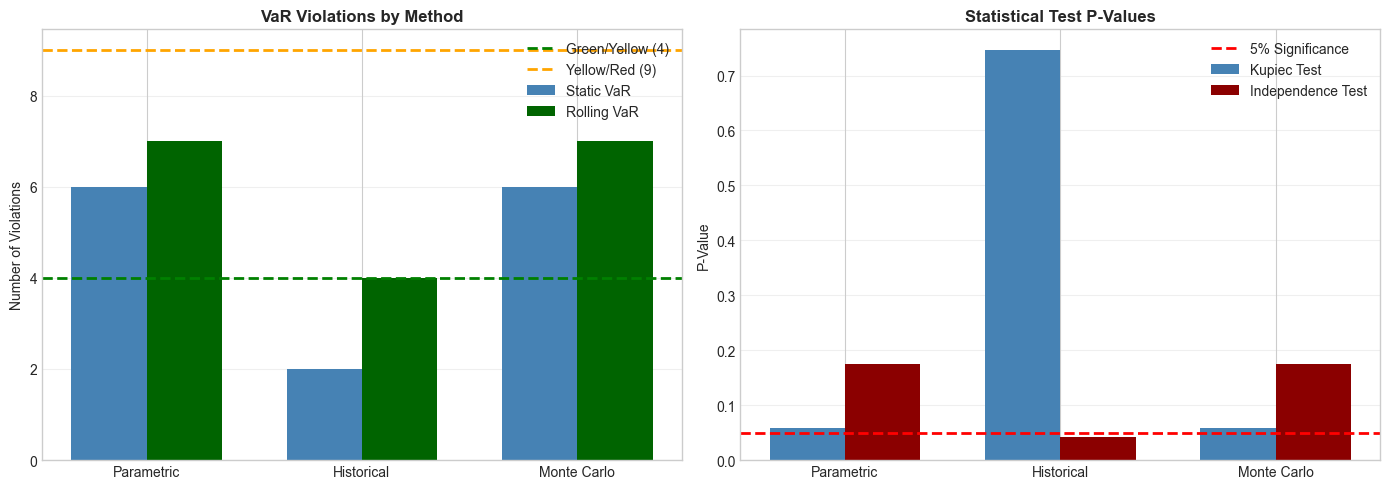

In [16]:
# Visualization: Model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Violations comparison
ax1 = axes[0]
methods = ['Parametric', 'Historical', 'Monte Carlo']
static_viols = [static_results[m]['violations'] for m in methods]
rolling_viols = [rolling_summary.loc[rolling_summary['Method']==m, 'Violations'].values[0] for m in methods]

x = np.arange(len(methods))
width = 0.35

bars1 = ax1.bar(x - width/2, static_viols, width, label='Static VaR', color='steelblue')
bars2 = ax1.bar(x + width/2, rolling_viols, width, label='Rolling VaR', color='darkgreen')

# Basel zone lines
ax1.axhline(4, color='green', linestyle='--', linewidth=2, label='Green/Yellow (4)')
ax1.axhline(9, color='orange', linestyle='--', linewidth=2, label='Yellow/Red (9)')

ax1.set_ylabel('Number of Violations')
ax1.set_title('VaR Violations by Method', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(methods)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# Right: P-values
ax2 = axes[1]
kupiec_pvals = [kupiec_results[m]['p_value'] for m in methods]
chris_pvals = [chris_results[m]['p_value'] for m in methods]

bars1 = ax2.bar(x - width/2, kupiec_pvals, width, label='Kupiec Test', color='steelblue')
bars2 = ax2.bar(x + width/2, chris_pvals, width, label='Independence Test', color='darkred')

ax2.axhline(0.05, color='red', linestyle='--', linewidth=2, label='5% Significance')

ax2.set_ylabel('P-Value')
ax2.set_title('Statistical Test P-Values', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(methods)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('../outputs/figures/06_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 6.8 Save Results

In [17]:
# Save backtesting results
backtest_results = {
    'static': {m: {k: v for k, v in r.items() if k not in ['violation_dates', 'violation_returns']} 
               for m, r in static_results.items()},
    'kupiec': kupiec_results,
    'christoffersen': chris_results
}

with open('../outputs/backtest_results.json', 'w') as f:
    json.dump(backtest_results, f, indent=4, default=str)

print("Backtesting results saved to outputs/backtest_results.json")

Backtesting results saved to outputs/backtest_results.json


---

## Summary

In this notebook, we performed comprehensive VaR backtesting:

### Basel III Framework

| Zone | Threshold | Capital Impact |
|------|-----------|---------------|
| Green | 0-4 violations | No increase |
| Yellow | 5-9 violations | +40-85% multiplier |
| Red | 10+ violations | +100% multiplier |

### Statistical Tests

| Test | Purpose | Null Hypothesis |
|------|---------|----------------|
| Kupiec (POF) | Correct violation rate | Observed = Expected rate |
| Christoffersen | Independent violations | Violations are i.i.d. |

### Key Findings

1. Basel Zone classification for each VaR model
2. Statistical validation of model accuracy
3. Independence of violations (no clustering)

**Next Steps:**
In Notebook 07, we will implement stress testing using historical and hypothetical scenarios.